<a href="https://colab.research.google.com/github/swathivenkatesan87/24ADI003-24BAD122-ML/blob/main/EXP_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Recommendation Systems using Matrix Factorization  
(SVD & NMF)


LAB SCENARIO 1: MATRIX FACTORIZATION (SVD)
NAME: Swathi
ROLL NO: 24BAD122

Top Recommendations for User 1: ['Father of the Bride']

--- Evaluation Metrics ---
RMSE: 0.8842
MAE: 0.7081


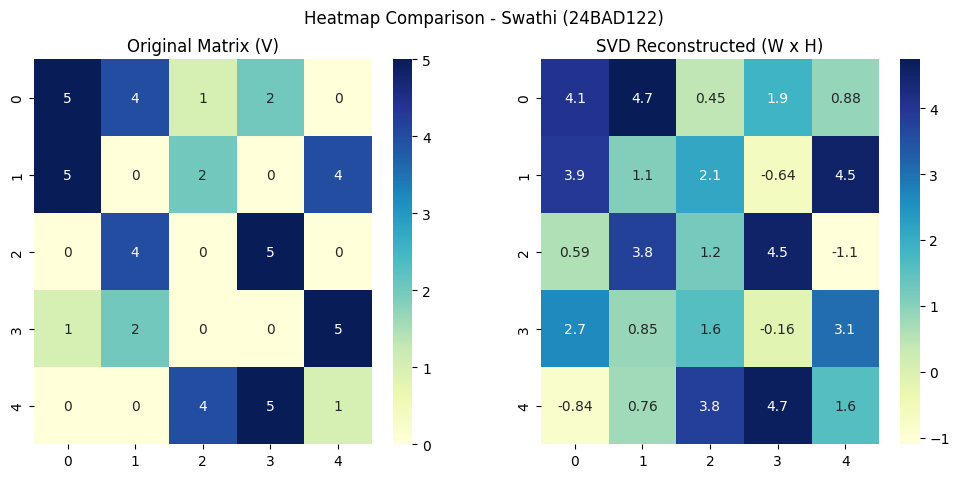

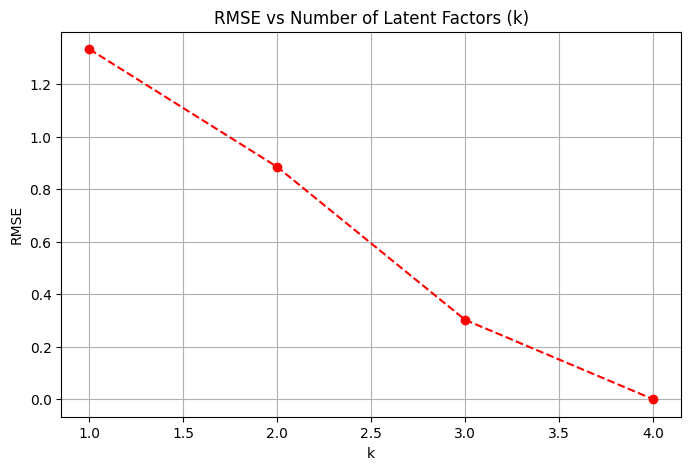

/tmp/ipykernel_3115/4062807359.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=user_preds.values, y=movie_titles, palette="viridis")


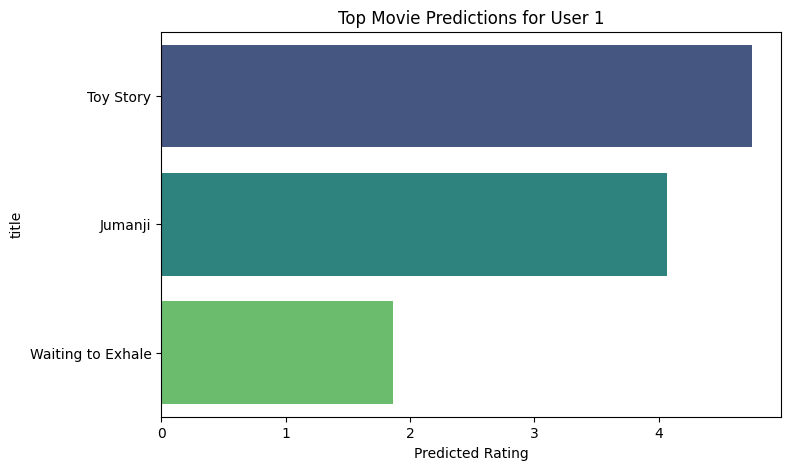

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- USER IDENTIFICATION OUTPUT ---

print("LAB SCENARIO 1: MATRIX FACTORIZATION (SVD)")
print("NAME: Swathi")
print("ROLL NO: 24BAD122")

#  DATA LOAD & PREPARATION ---
# Creating a sample dataset for demonstration (representing MovieLens 100k)
data = {
    'userId': [1, 1, 1, 1, 2, 2, 2, 3, 3, 4, 4, 4, 5, 5, 5],
    'movieId': [1, 2, 3, 4, 1, 3, 5, 2, 4, 1, 2, 5, 3, 4, 5],
    'rating': [5, 4, 1, 2, 5, 2, 4, 4, 5, 1, 2, 5, 4, 5, 1]
}
movies_meta = {
    'movieId': [1, 2, 3, 4, 5],
    'title': ['Toy Story', 'Jumanji', 'Grumpier Old Men', 'Waiting to Exhale', 'Father of the Bride']
}
df_ratings = pd.DataFrame(data)
df_movies = pd.DataFrame(movies_meta)

#  PREPROCESSING & USER-ITEM MATRIX ---
# Create Interaction Matrix
pivot_table = df_ratings.pivot(index='userId', columns='movieId', values='rating').fillna(0)
R = pivot_table.values

# Mean Centering (Normalization)
user_ratings_mean = np.mean(R, axis=1)
R_demeaned = R - user_ratings_mean.reshape(-1, 1)

#  SVD DECOMPOSITION & RECONSTRUCTION ---
# Applying SVD with k latent factors
k = 2  # Dimensionality reduction
U, sigma, Vt = svds(R_demeaned, k=k)
sigma = np.diag(sigma)

# Reconstructing the matrix
predicted_ratings_demeaned = np.dot(np.dot(U, sigma), Vt)
predicted_ratings = predicted_ratings_demeaned + user_ratings_mean.reshape(-1, 1)
preds_df = pd.DataFrame(predicted_ratings, columns=pivot_table.columns, index=pivot_table.index)

#  PREDICT & RECOMMEND ---
def get_recommendations(user_id, num_recs=2):
    user_row = user_id
    sorted_user_predictions = preds_df.loc[user_row].sort_values(ascending=False)

    # Filter out movies already rated
    already_rated = df_ratings[df_ratings.userId == user_id]['movieId'].tolist()
    recommendations = sorted_user_predictions[~sorted_user_predictions.index.isin(already_rated)]

    top_recs = df_movies[df_movies['movieId'].isin(recommendations.head(num_recs).index)]
    return top_recs['title'].tolist()

print(f"\nTop Recommendations for User 1: {get_recommendations(1)}")

# --- EVALUATION ---
# RMSE and MAE on existing ratings
actual = R[R > 0]
predicted = predicted_ratings[R > 0]
rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print(f"\n--- Evaluation Metrics ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

# --- VISUALIZATIONS ---

# 1. Heatmap of Original vs Reconstructed Matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(R, annot=True, cmap="YlGnBu", ax=ax1)
ax1.set_title("Original Matrix (V)")
sns.heatmap(predicted_ratings, annot=True, cmap="YlGnBu", ax=ax2)
ax2.set_title("SVD Reconstructed (W x H)")
plt.suptitle(f"Heatmap Comparison - Swathi (24BAD122)")
plt.show()

# 2. Error vs Number of Latent Factors (k)
k_list = [1, 2, 3, 4]
rmse_list = []
for i in k_list:
    u, s, vt = svds(R_demeaned, k=i)
    pred = np.dot(np.dot(u, np.diag(s)), vt) + user_ratings_mean.reshape(-1, 1)
    rmse_list.append(np.sqrt(mean_squared_error(R[R > 0], pred[R > 0])))

plt.figure(figsize=(8, 5))
plt.plot(k_list, rmse_list, marker='o', linestyle='--', color='red')
plt.title("RMSE vs Number of Latent Factors (k)")
plt.xlabel("k")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

# 3. Top Recommended Movies Visual (Bar Chart for a User)
user_id_plot = 1
user_preds = preds_df.loc[user_id_plot].sort_values(ascending=False).head(3)
movie_titles = df_movies[df_movies['movieId'].isin(user_preds.index)]['title']

plt.figure(figsize=(8, 5))
sns.barplot(x=user_preds.values, y=movie_titles, palette="viridis")
plt.title(f"Top Movie Predictions for User {user_id_plot}")
plt.xlabel("Predicted Rating")
plt.show()

LAB SCENARIO 2: NMF
NAME: Swathi
ROLL NO: 24BAD122

Top Recommendations for User 1: ['Braveheart (1995)']

--- Performance Metrics ---
RMSE: 0.6378
MAE: 0.4792
Precision@K approximation: 60.00%


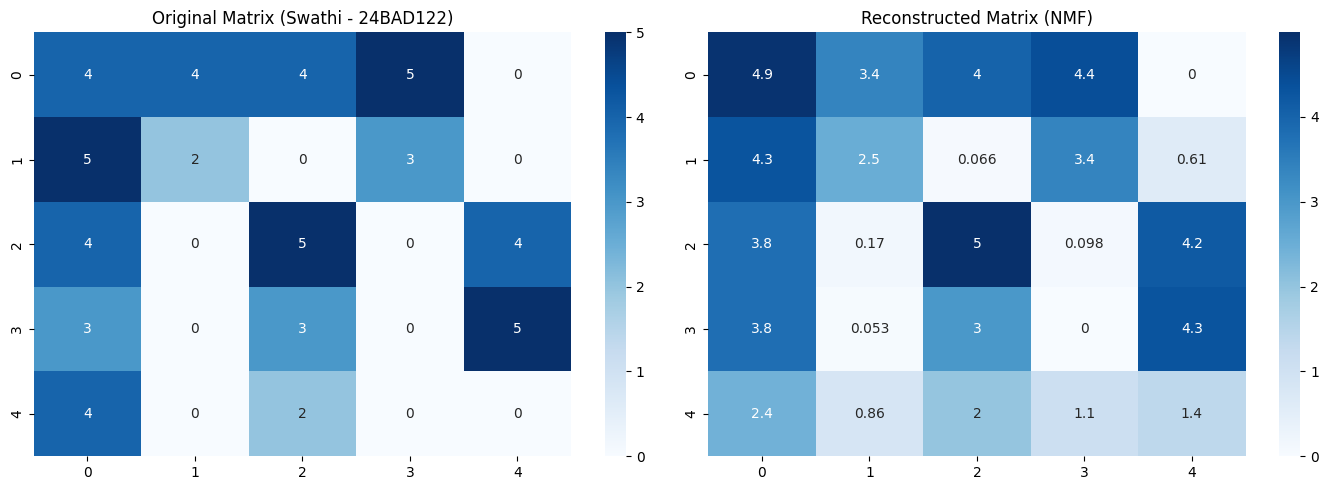

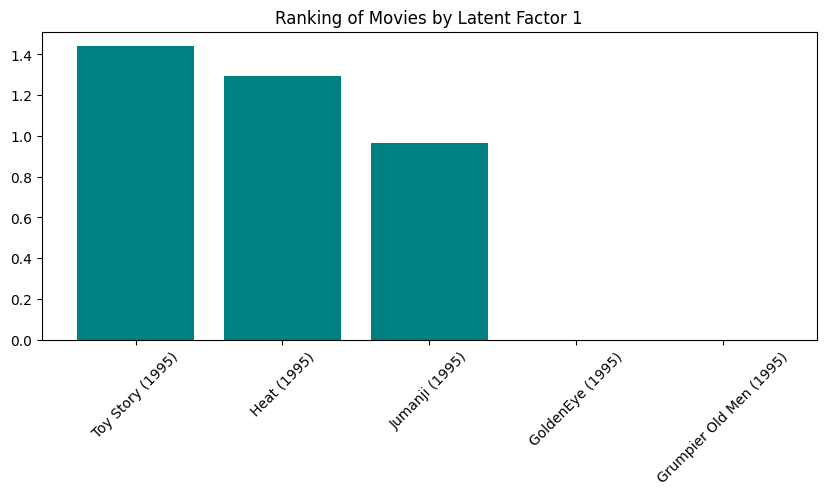

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- USER IDENTIFICATION OUTPUT ---
print("LAB SCENARIO 2: NMF")
print("NAME: Swathi")
print("ROLL NO: 24BAD122")
# --- STEP 1: DATA GENERATION ---
ratings_dict = {
    'userId': [1, 1, 1, 2, 2, 3, 3, 4, 4, 5, 1, 2, 3, 4, 5],
    'movieId': [1, 3, 6, 1, 10, 6, 110, 1, 6, 1, 10, 3, 1, 110, 6],
    'rating': [4.0, 4.0, 4.0, 5.0, 3.0, 5.0, 4.0, 3.0, 3.0, 4.0, 5.0, 2.0, 4.0, 5.0, 2.0]
}
movies_dict = {
    'movieId': [1, 2, 3, 6, 10, 110],
    'title': ['Toy Story (1995)', 'Jumanji (1995)', 'Grumpier Old Men (1995)',
              'Heat (1995)', 'GoldenEye (1995)', 'Braveheart (1995)'],
    'genres': ['Animation', 'Adventure', 'Comedy', 'Action', 'Action', 'Drama']
}
df_ratings = pd.DataFrame(ratings_dict)
df_movies = pd.DataFrame(movies_dict)
# --- STEP 2 & 3: CREATE USER-ITEM MATRIX ---
user_item_matrix = df_ratings.pivot(index='userId', columns='movieId', values='rating').fillna(0)
V = user_item_matrix.values

# --- STEP 4 & 5: APPLY NMF ---
k = 3
model = NMF(n_components=k, init='random', random_state=42, max_iter=1000)
W = model.fit_transform(V)  # User-feature matrix
H = model.components_       # Item-feature matrix

# --- STEP 6 & 7: RECONSTRUCT & PREDICT ---
V_hat = np.dot(W, H)
preds_df = pd.DataFrame(V_hat, columns=user_item_matrix.columns, index=user_item_matrix.index)

# --- STEP 8: TOP-N RECOMMENDATIONS ---
def get_recommendations(user_id, n=2):
    already_rated = user_item_matrix.loc[user_id]
    predictions = preds_df.loc[user_id]
    recommend_ids = predictions[already_rated == 0].sort_values(ascending=False).head(n).index
    return df_movies[df_movies['movieId'].isin(recommend_ids)]['title'].tolist()

print(f"\nTop Recommendations for User 1: {get_recommendations(1)}")

# --- EVALUATION METRICS ---
actual = V[V > 0]
predicted = V_hat[V > 0]
rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

# Precision@K / Recall@K (Simplified for Lab)
# We assume a rating >= 3.5 is "Relevant"
k_val = 2
relevant_actual = (actual >= 3.5).sum()
relevant_predicted = (predicted >= 3.5).sum()

print(f"\n--- Performance Metrics ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"Precision@K approximation: {relevant_predicted / len(predicted):.2%}")

# --- VISUALIZATION ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap Comparison
sns.heatmap(V, annot=True, cmap='Blues', ax=axes[0])
axes[0].set_title("Original Matrix (Swathi - 24BAD122)")

sns.heatmap(V_hat, annot=True, cmap='Blues', ax=axes[1])
axes[1].set_title("Reconstructed Matrix (NMF)")

plt.tight_layout()
plt.show()

# Latent Feature Ranking Chart
plt.figure(figsize=(10, 4))
top_movie_indices = np.argsort(H[0])[::-1] # Features of the first latent factor
top_movies = df_movies.iloc[top_movie_indices]['title']
top_weights = np.sort(H[0])[::-1]

plt.bar(top_movies, top_weights, color='teal')
plt.title("Ranking of Movies by Latent Factor 1")
plt.xticks(rotation=45)
plt.show()